# Purpose
to ingest Sarah's skokholm data and start plotting! then to answer some basic questions about how mice move and maybe survive


Info from readme in folder:
There are three key logger data files produced using the code outlined in 'logger_data_organization.Rmd'. These represent a kind of 'checkpoint' for processing of the logger data.

1. all-logger-reads_20240821.rds: This is a dataframe that contains all of the logger pings, regardless of whether it recorded a PIT tag. No cleaning or corrections have been made, this dataset simply represents a concatenation of all of the logger entries.

2. PIT-tag-reads_20240821.rds: This data file now also contains metadata as to the location of loggers. Some cleaning has been performed to remove 'reads' that lack date/time information. This data file also only includes logger observations that correspond to PIT tag reads.

3. capture-data-matched-tag-reads_20240821.rds: This data file is the same as above, but retains only PIT reads that match to metadata entries in the capture data. The unclean file above contains a lot of erroneous reads like "X041A\x9f\xe8C5FB"

The second RMD, "skokholm_SRI-estimates_20240821.Rmd", contains code (repurposed from Aura's scripts) to build a social network. It will use the "capture-data-matched-tag-reads_20240821.rds" file as the input (quality controlled PIT tag reads with matched location and time/date data). Ultimately, you will need to decide whether to use only a subset of the data (when many loggers are active) or all of the data. Similarly, a key parameter to decide, is the degree of temporal overlap required for any two individuals to be considered 'associated'. This parameter can be specified on the second line of code in the "B) CONSTRUCTING the GBI and GD matrices...." section. 

Capture metadata files and logger location files were acquired from the lab google drive. 

# imports

In [2]:
import pandas as pd
import numpy as np 
import math, os, sys
import matplotlib.pyplot as plt 
from haversine import haversine, Unit

In [3]:
os.path.isfile('/Users/dennise/Desktop/skok25/skok_logger/all-logger-reads_20240821.rds')

True

# Procedure

In [4]:
os.listdir('../../../skok25/skok_logger')

['all-logger-reads_20240821.csv',
 'all-logger-reads_20240821.rds',
 'capture-data-matched-tag-reads_20240821.csv',
 'capture-data-matched-tag-reads_20240821.rds',
 'logger_data_organization.Rmd',
 'logger_locations.csv',
 'Logger_locations_across_all_trips.csv',
 'PIT-tag-reads_20240821.csv',
 'PIT-tag-reads_20240821.rds',
 'plots',
 'README.txt',
 'Sep22Apr23_loggers',
 'sept2022apr2023loggers',
 'skokholm_SRI-estimates_20240821.Rmd',
 'skok_capture_2024-05-21.csv',
 'skok_logger_organization_sri_20240821']

In [5]:
capturereads = pd.read_csv("/Users/dennise/Desktop/skok25/skok_logger/capture-data-matched-tag-reads_20240821.csv",index_col=0)
capturereads.columns=['Tag_IDX', 'location_found_cleaned', 'logger_id_season', 'datetime',
       'LOGGER_ID', 'WIRELESS_ID', 'motion_det', 'tempC', 'hum.', 'AMP1ADC',
       'AMP2ADC', 'batV_L', 'batV_NL', 'int.tempC', 'Tag_ID', 'Err', 'Line',
       'Pdir', 'ext.tempC', 'Comment', 'Day', 'Month', 'Yearx', 'Hours',
       'Minutes', 'Seconds', 'logger_season', 'logger_id', 'location_found',
       'trip', 'Yeary', 'Trapping_date', 'collection_date', 'Season',
       'Trapping_site', 'Trapping_point', 'Garmin_GPS', 'Garmin_ID',
       'GPS_latitude', 'GPS_longitude', 'No_trappingpoints', 'Comments',
       'Merge_GPS_coordinates_by', 'unique_flag_location', 'datetime2',
       'time_difference', 'preceding_same', 'first_value', 'winter_interval',
       'date_actual', 'date', 'mouse_ID', 'tag_id', 'dummy']

C:\Users\dennise\AppData\Local\Temp\ipykernel_7576\2190805515.py:1: DtypeWarning: Columns (8,47) have mixed types. Specify dtype option on import or set low_memory=False.
  capturereads = pd.read_csv("/Users/dennise/Desktop/skok25/skok_logger/capture-data-matched-tag-reads_20240821.csv",index_col=0)


In [6]:
print(len(np.unique(capturereads.Tag_ID)))

328


In [7]:
print(np.min(capturereads.GPS_latitude), np.max(capturereads.GPS_latitude))
print(np.min(capturereads.GPS_longitude), np.max(capturereads.GPS_longitude))

minlat=np.min(capturereads.GPS_latitude)
minlong=np.min(capturereads.GPS_longitude)
arbit_dist=[]

for idx in capturereads.index:
    lat=capturereads.loc[idx,'GPS_latitude']
    long=capturereads.loc[idx,'GPS_longitude']
    arbit_dist.append(haversine((minlat,minlong),(lat,long)))
capturereads['arbit_dist']=arbit_dist

51.69383498 51.70237396
-5.288155032 -5.273210015


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


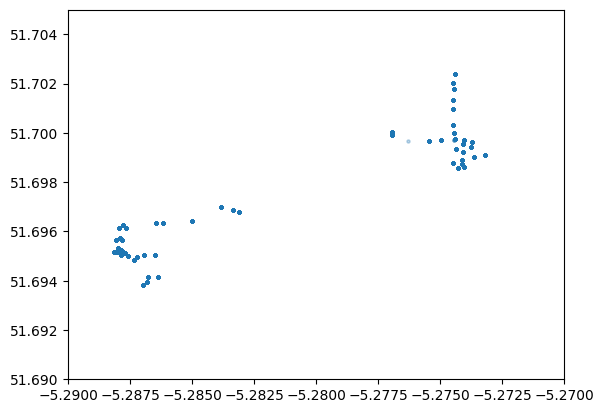

In [8]:
plt.scatter(capturereads.GPS_longitude,capturereads.GPS_latitude, s=5, alpha=0.1)
plt.xlim(-5.29,-5.27)
plt.ylim(51.69,51.705)
plt.savefig('/Users/dennise/Desktop/skok25/skok_logger/plots/locations_all.eps', bbox_inches='tight')

In [9]:
capturereads.columns

Index(['Tag_IDX', 'location_found_cleaned', 'logger_id_season', 'datetime',
       'LOGGER_ID', 'WIRELESS_ID', 'motion_det', 'tempC', 'hum.', 'AMP1ADC',
       'AMP2ADC', 'batV_L', 'batV_NL', 'int.tempC', 'Tag_ID', 'Err', 'Line',
       'Pdir', 'ext.tempC', 'Comment', 'Day', 'Month', 'Yearx', 'Hours',
       'Minutes', 'Seconds', 'logger_season', 'logger_id', 'location_found',
       'trip', 'Yeary', 'Trapping_date', 'collection_date', 'Season',
       'Trapping_site', 'Trapping_point', 'Garmin_GPS', 'Garmin_ID',
       'GPS_latitude', 'GPS_longitude', 'No_trappingpoints', 'Comments',
       'Merge_GPS_coordinates_by', 'unique_flag_location', 'datetime2',
       'time_difference', 'preceding_same', 'first_value', 'winter_interval',
       'date_actual', 'date', 'mouse_ID', 'tag_id', 'dummy', 'arbit_dist'],
      dtype='object')

In [10]:
capturereads=capturereads.sort_values(by='date_actual')

In [11]:
len(np.unique(capturereads.Tag_ID))

328

In [12]:
survivors = []
migrants=[]

for tag in np.unique(capturereads.Tag_ID):
    # if capturereads.GPS_longitude > 5.28 and < 5.28 they've been near obs/near quarry
    if len(np.unique(capturereads[capturereads.Tag_ID == tag].Yearx))>1:
        survivors.append(tag)
    tempdf = capturereads[capturereads.Tag_ID == tag]
    if tempdf.GPS_longitude.max() > -5.28 and tempdf.GPS_longitude.min() < -5.28:
        migrants.append(tag)
print('migrants: ', len(migrants),'survivors: ',len(survivors))

migrants:  3 survivors:  49


In [13]:
capturereads[['LOGGER_ID','GPS_longitude','GPS_latitude','date_actual']][capturereads.Tag_ID=='041A1F2373']

,LOGGER_ID,GPS_longitude,GPS_latitude,date_actual
2119,0803,-5.274126,51.698737,2021-09-30
2117,0803,-5.274126,51.698737,2021-09-30
2129,0803,-5.274126,51.698737,2021-09-30
2121,0803,-5.274126,51.698737,2021-09-30
2112,0803,-5.274126,51.698737,2021-10-11
2109,0803,-5.274126,51.698737,2021-10-11
2111,0803,-5.274126,51.698737,2021-10-11
2131,0867,-5.286771,51.694155,2021-10-25
2120,0867,-5.286771,51.694155,2021-10-25
2110,0867,-5.286771,51.694155,2021-10-25


In [14]:
migrants

['041A1F2373', '041A1F2EEA', '041A1F4430']

26 23


Text(0.5, 1.0, 'NOTE this is only looking at the **first** place this mouse was seen \n does not include over-wintering location, \n need a more nuanced approach')

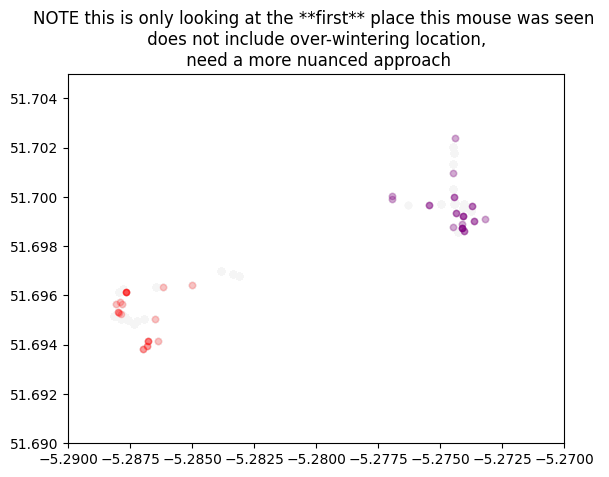

In [15]:
obssurv=0
quarrysurv=0
survlist=[]
fig,ax=plt.subplots(1,1)
ax.scatter(capturereads.GPS_longitude,capturereads.GPS_latitude , s=20, c='whitesmoke')
ax.set_xlim(-5.29,-5.27)
ax.set_ylim(51.69,51.705)
for survivor in survivors: 
    if list(capturereads.GPS_longitude[capturereads.Tag_ID == survivor])[0] > -5.280:
        plt.scatter(list(capturereads.GPS_longitude[capturereads.Tag_ID == survivor])[0],list(capturereads.GPS_latitude[capturereads.Tag_ID == survivor])[0], c='purple',alpha=0.3,s=20)
        obssurv+=1
        survlist.append(0)
    else:
        quarrysurv+=1
        survlist.append(1) 
        plt.scatter(list(capturereads.GPS_longitude[capturereads.Tag_ID == survivor])[0],list(capturereads.GPS_latitude[capturereads.Tag_ID == survivor])[0], c='r',alpha=0.2,s=20)
print(obssurv, quarrysurv)
ax.set_title('NOTE this is only looking at the **first** place this mouse was seen \n does not include over-wintering location, \n need a more nuanced approach')
#ax.set_facecolor('black')
# specifically should get most wintery location I think... but knowing that at least a few migrate


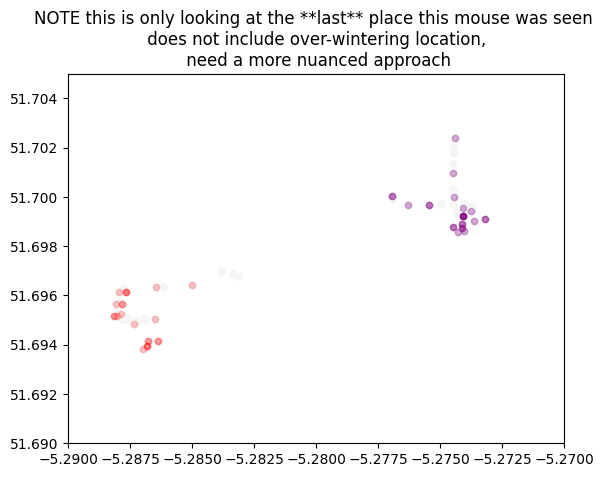

26 23


In [16]:
obssurv_end=0
quarrysurv_end=0
survlist_end=[]
plt.scatter(capturereads.GPS_longitude,capturereads.GPS_latitude , s=20, c='whitesmoke')
for survivor in survivors: 
    if list(capturereads.GPS_longitude[capturereads.Tag_ID == survivor])[0] > -5.280:
        plt.scatter(list(capturereads.GPS_longitude[capturereads.Tag_ID == survivor])[-1],list(capturereads.GPS_latitude[capturereads.Tag_ID == survivor])[-1], c='purple',alpha=0.3,s=20)
        obssurv_end+=1
        survlist_end.append(0)
    else:
        quarrysurv_end+=1
        survlist_end.append(1) 
        plt.scatter(list(capturereads.GPS_longitude[capturereads.Tag_ID == survivor])[-1],list(capturereads.GPS_latitude[capturereads.Tag_ID == survivor])[-1], c='r',alpha=0.2,s=20)
plt.xlim(-5.29,-5.27)
plt.ylim(51.69,51.705)
plt.title('NOTE this is only looking at the **last** place this mouse was seen \n does not include over-wintering location, \n need a more nuanced approach')
plt.show()
print(obssurv_end,quarrysurv_end)
# specifically should get most wintery location I think... but knowing that at least a few migrate


In [18]:
capturereads['yearmonth'] = capturereads.Yearx + (capturereads.Month/13)

In [19]:
migrants #check 041abbc507, 041abbcb40

['041A1F2373', '041A1F2EEA', '041A1F4430']

In [ ]:
'''
for migrant in migrants:
    plt.scatter(capturereads.GPS_longitude[capturereads.Tag_ID == migrant],capturereads.GPS_latitude[capturereads.Tag_ID == migrant], s=5, c = capturereads.yearmonth[capturereads.Tag_ID == migrant], alpha=0.1)
    plt.colorbar()
    plt.xlim(-5.29,-5.27)
    plt.ylim(51.69,51.705)
    plt.savefig('/Users/dennise/Desktop/skok25/skok_logger/plots/_migrant_locations_{}.eps'.format(migrant), bbox_inches='tight')
    plt.close()
    '''

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


In [21]:
for migrant in migrants:
    print(migrant,np.min(capturereads.yearmonth[capturereads.Tag_ID == migrant]), np.max(capturereads.yearmonth[capturereads.Tag_ID == migrant]))

041A1F2373 21.692307692307693 21.923076923076923
041A1F2EEA 21.692307692307693 22.23076923076923
041A1F4430 21.692307692307693 21.692307692307693


In [22]:
np.unique(capturereads.GPS_longitude[capturereads.Tag_ID=="041A1F2EEA"])

array([-5.28639902, -5.27412599, -5.27405801])

In [23]:
'''
for tag in np.unique(capturereads.Tag_ID):
    if tag not in survivors:
        plt.scatter(capturereads.GPS_latitude,capturereads.GPS_longitude , s=10, c='whitesmoke')
        plt.scatter(capturereads.GPS_latitude[capturereads.Tag_ID == tag],capturereads.GPS_longitude[capturereads.Tag_ID == tag] , s=20,c=capturereads.Yearx[capturereads.Tag_ID == tag]+(capturereads.Month[capturereads.Tag_ID == tag]/13),cmap='plasma')
        plt.colorbar()
        plt.ylim(-5.29,-5.27)
        plt.xlim(51.69,51.705)
        plt.clim(20,23)
        plt.savefig('/Users/dennise/Desktop/skok25/skok_logger/plots/locations_'+tag+'.png', dpi=300, bbox_inches='tight')
        plt.close()
'''

# want to calculate a bunch of stuff, dropping ideas here for now:
-  distance (max) for each mouse
- for each night, what's the # of mice seen? are there good nights/bad nights? can we see die-off with these data?
- for each mouse, how often do we expect to see them consecutively?
- what is a normal range for a mouse per night? week? month? season?
- questions about the data: 
    - do we have the capture data or just pit tags here? seems like just pit tags, but the capture data should be in this folder somewhere... need to dig back into the readme/rmd files since they explain where the data came from and how it was pruned. 
    - what about mice assigned multiple RFIDs or lost RFIDs? are they showing up as different mice or same mouse?
- there seem to be three mice who have traversed the island, one of them twice!! this implies migration is more rare then we thought... 
- there seem to be 49 survivors...

In [24]:
capturereads.columns

Index(['Tag_IDX', 'location_found_cleaned', 'logger_id_season', 'datetime',
       'LOGGER_ID', 'WIRELESS_ID', 'motion_det', 'tempC', 'hum.', 'AMP1ADC',
       'AMP2ADC', 'batV_L', 'batV_NL', 'int.tempC', 'Tag_ID', 'Err', 'Line',
       'Pdir', 'ext.tempC', 'Comment', 'Day', 'Month', 'Yearx', 'Hours',
       'Minutes', 'Seconds', 'logger_season', 'logger_id', 'location_found',
       'trip', 'Yeary', 'Trapping_date', 'collection_date', 'Season',
       'Trapping_site', 'Trapping_point', 'Garmin_GPS', 'Garmin_ID',
       'GPS_latitude', 'GPS_longitude', 'No_trappingpoints', 'Comments',
       'Merge_GPS_coordinates_by', 'unique_flag_location', 'datetime2',
       'time_difference', 'preceding_same', 'first_value', 'winter_interval',
       'date_actual', 'date', 'mouse_ID', 'tag_id', 'dummy', 'arbit_dist',
       'yearmonth'],
      dtype='object')

In [25]:
print(len(np.unique(capturereads.mouse_ID)))
print(len(np.unique(capturereads.Tag_ID)))

323
328


### max distance travelled for each mouse

In [ ]:
# distance (max) for each mouse, I guess start in GPS long/lat
check_in_nos=[]
max_dists=[]
for mouse in np.unique(capturereads.mouse_ID):
  mousedf=capturereads[capturereads.mouse_ID==mouse].reset_index(drop=True)
  check_in_nos.append(len(mousedf))
  
  unique_lats = np.unique(mousedf.GPS_latitude)
  dists=[]
  # for each unique_reader for this mouse, get the distance between the readers
  for lat_a in unique_lats:
    long_a=np.unique(mousedf.loc[lambda mousedf: mousedf.GPS_latitude==lat_a, lambda df: ['GPS_longitude']])[0]
    for lat_b in unique_lats:
      long_b=np.unique(mousedf.loc[lambda mousedf: mousedf.GPS_latitude==lat_b, lambda df: ['GPS_longitude']])[0]
      dists.append(haversine((lat_a,long_a),(lat_b,long_b),unit=Unit.METERS))    
  max_dists.append(np.max(dists))


In [ ]:
mouse_stat_df=pd.DataFrame(columns=['mouse','max_dists','no_checkins'])
mouse_stat_df.max_dists=max_dists 
mouse_stat_df.no_checkins = check_in_nos
mouse_stat_df.mouse = np.unique(capturereads.mouse_ID)
travelers = mouse_stat_df.index[mouse_stat_df.max_dists>200]
print(travelers)

Index([18, 75, 132, 145, 148, 174, 191, 304, 316, 321], dtype='int64')


## TODO 
probably can use the above structure to get all distances based on the arbit_dist... by night seems like a doable stat (if seen at all, get a distance) but would want NIGHTS not dates which is... annoying

In [45]:
x=9
print(len(mouse_stat_df[mouse_stat_df.no_checkins>x])/len(mouse_stat_df))
print(mouse_stat_df.columns)

0.7337461300309598
Index(['mouse', 'max_dists', 'no_checkins'], dtype='object')


In [29]:
capturereads.columns

Index(['Tag_IDX', 'location_found_cleaned', 'logger_id_season', 'datetime',
       'LOGGER_ID', 'WIRELESS_ID', 'motion_det', 'tempC', 'hum.', 'AMP1ADC',
       'AMP2ADC', 'batV_L', 'batV_NL', 'int.tempC', 'Tag_ID', 'Err', 'Line',
       'Pdir', 'ext.tempC', 'Comment', 'Day', 'Month', 'Yearx', 'Hours',
       'Minutes', 'Seconds', 'logger_season', 'logger_id', 'location_found',
       'trip', 'Yeary', 'Trapping_date', 'collection_date', 'Season',
       'Trapping_site', 'Trapping_point', 'Garmin_GPS', 'Garmin_ID',
       'GPS_latitude', 'GPS_longitude', 'No_trappingpoints', 'Comments',
       'Merge_GPS_coordinates_by', 'unique_flag_location', 'datetime2',
       'time_difference', 'preceding_same', 'first_value', 'winter_interval',
       'date_actual', 'date', 'mouse_ID', 'tag_id', 'dummy', 'arbit_dist',
       'yearmonth'],
      dtype='object')

In [71]:
np.unique(capturereads.Yearx)

array([20, 21, 22, 23])

In [ ]:
nights=list(capturereads.Day)
capturereads=capturereads.reset_index(drop=True)
for idx in capturereads.index:
    if capturereads.Hours[idx] < 8:
        print(idx)
        nights[idx]+=-1
capturereads['night']=nights
capturereads.night+=1



0
1
2
7
66
74
82
85
90
99
100
101
104
110
111
112
113
115
120
122
124
128
130
139
155
156
158
162
163
179
181
182
186
187
189
190
191
192
193
194
195
196
197
198
200
201
202
203
205
206
207
208
209
210
211
219
220
223
225
227
230
233
235
241
243
247
248
249
250
251
255
264
314
315
316
317
318
319
320
321
323
324
325
326
327
328
329
330
331
333
334
337
338
340
342
344
346
347
348
351
354
357
374
381
382
383
384
385
386
389
392
395
396
398
399
400
401
402
423
425
448
451
452
456
457
458
459
460
461
462
463
466
467
471
472
480
482
484
494
497
499
500
501
502
504
505
506
507
508
509
510
511
512
514
515
516
517
518
519
520
527
534
535
537
539
542
548
554
556
566
570
572
577
578
580
602
604
606
607
608
616
622
623
624
629
630
635
638
642
644
651
654
656
657
658
659
661
662
689
691
713
715
716
725
727
730
731
732
733
735
748
749
753
754
755
756
757
758
759
760
761
762
763
764
765
766
773
774
776
777
778
779
780
782
802
810
815
816
817
819
825
830
831
833
834
835
836
837
838
839
840
841
842
84

# TODO should prob fix nights==0, but for now...

In [211]:
capturereads['nightstr']="20"+capturereads.Yearx.astype(str)+"-"+capturereads.Month.apply(lambda x: f"{x:02d}")+"-"+capturereads.night.apply(lambda x: f"{x:02d}")

capturereads.nightstr

0        2020-09-06
1        2020-09-06
2        2020-09-06
3        2020-09-09
4        2020-09-09
            ...    
25224    2023-04-31
25225    2023-04-31
25226    2023-04-31
25227    2023-04-29
25228    2023-05-01
Name: nightstr, Length: 25229, dtype: object

In [212]:
# want dist travelled each night
# get all mice with 10+ checkins

# set up empty variables
all_mice=[]
num_loggers=[]
logger_list=[]
GPS_lats=[]
GPS_longs=[]
no_checkins = []
max_dists=[]
nights=[]
for mouse in list(mouse_stat_df.mouse[mouse_stat_df.no_checkins>8]):
    # get just this mouse's info
    subdf = capturereads[capturereads.mouse_ID==mouse]
    # set up empty variables
    # get all unique nights
    mousenights=np.unique(subdf.nightstr)
    for night in mousenights:
        # for each night, get loggers
        loggers=np.unique(subdf.LOGGER_ID[subdf.nightstr==night])
        distlist=[]
        mouselats =[]
        mouselongs=[]
        for logger in loggers:
            nights.append(night)
            all_mice.append(mouse)
            logger_list.append(logger)
            num_loggers.append(len(loggers))
            subsubdf = subdf[(subdf.nightstr==night) & (subdf.LOGGER_ID==logger)]
            no_checkins.append(len(subsubdf))
            curr_lat=list(subsubdf.GPS_latitude)[0]
            curr_long=list(subsubdf.GPS_longitude)[0]
            GPS_lats.append(curr_lat)
            mouselats.append(curr_lat)
            GPS_longs.append(curr_long)
            mouselongs.append(curr_long)
        for logger in loggers:
            for idx in np.arange(0,len(loggers)):
                distlist.append(haversine((curr_lat,curr_long),(mouselats[idx],mouselongs[idx]),unit=Unit.METERS)) #lat then lon
            max_dists.append(np.max(distlist))
mouse_night_df = pd.DataFrame(columns=['mouse','nightstr','num_loggers','loggers','GPS_lats','GPS_longs','no_checkins','max_dists'])
mouse_night_df.nightstr = nights
mouse_night_df.mouse = all_mice
mouse_night_df.num_loggers = num_loggers
mouse_night_df.loggers = logger_list
mouse_night_df.GPS_lats = GPS_lats
mouse_night_df.GPS_longs = GPS_longs
mouse_night_df.no_checkins = no_checkins
mouse_night_df.max_dists = max_dists


In [213]:
mouse_night_df.sort_values(by='nights')

KeyError: 'nights'

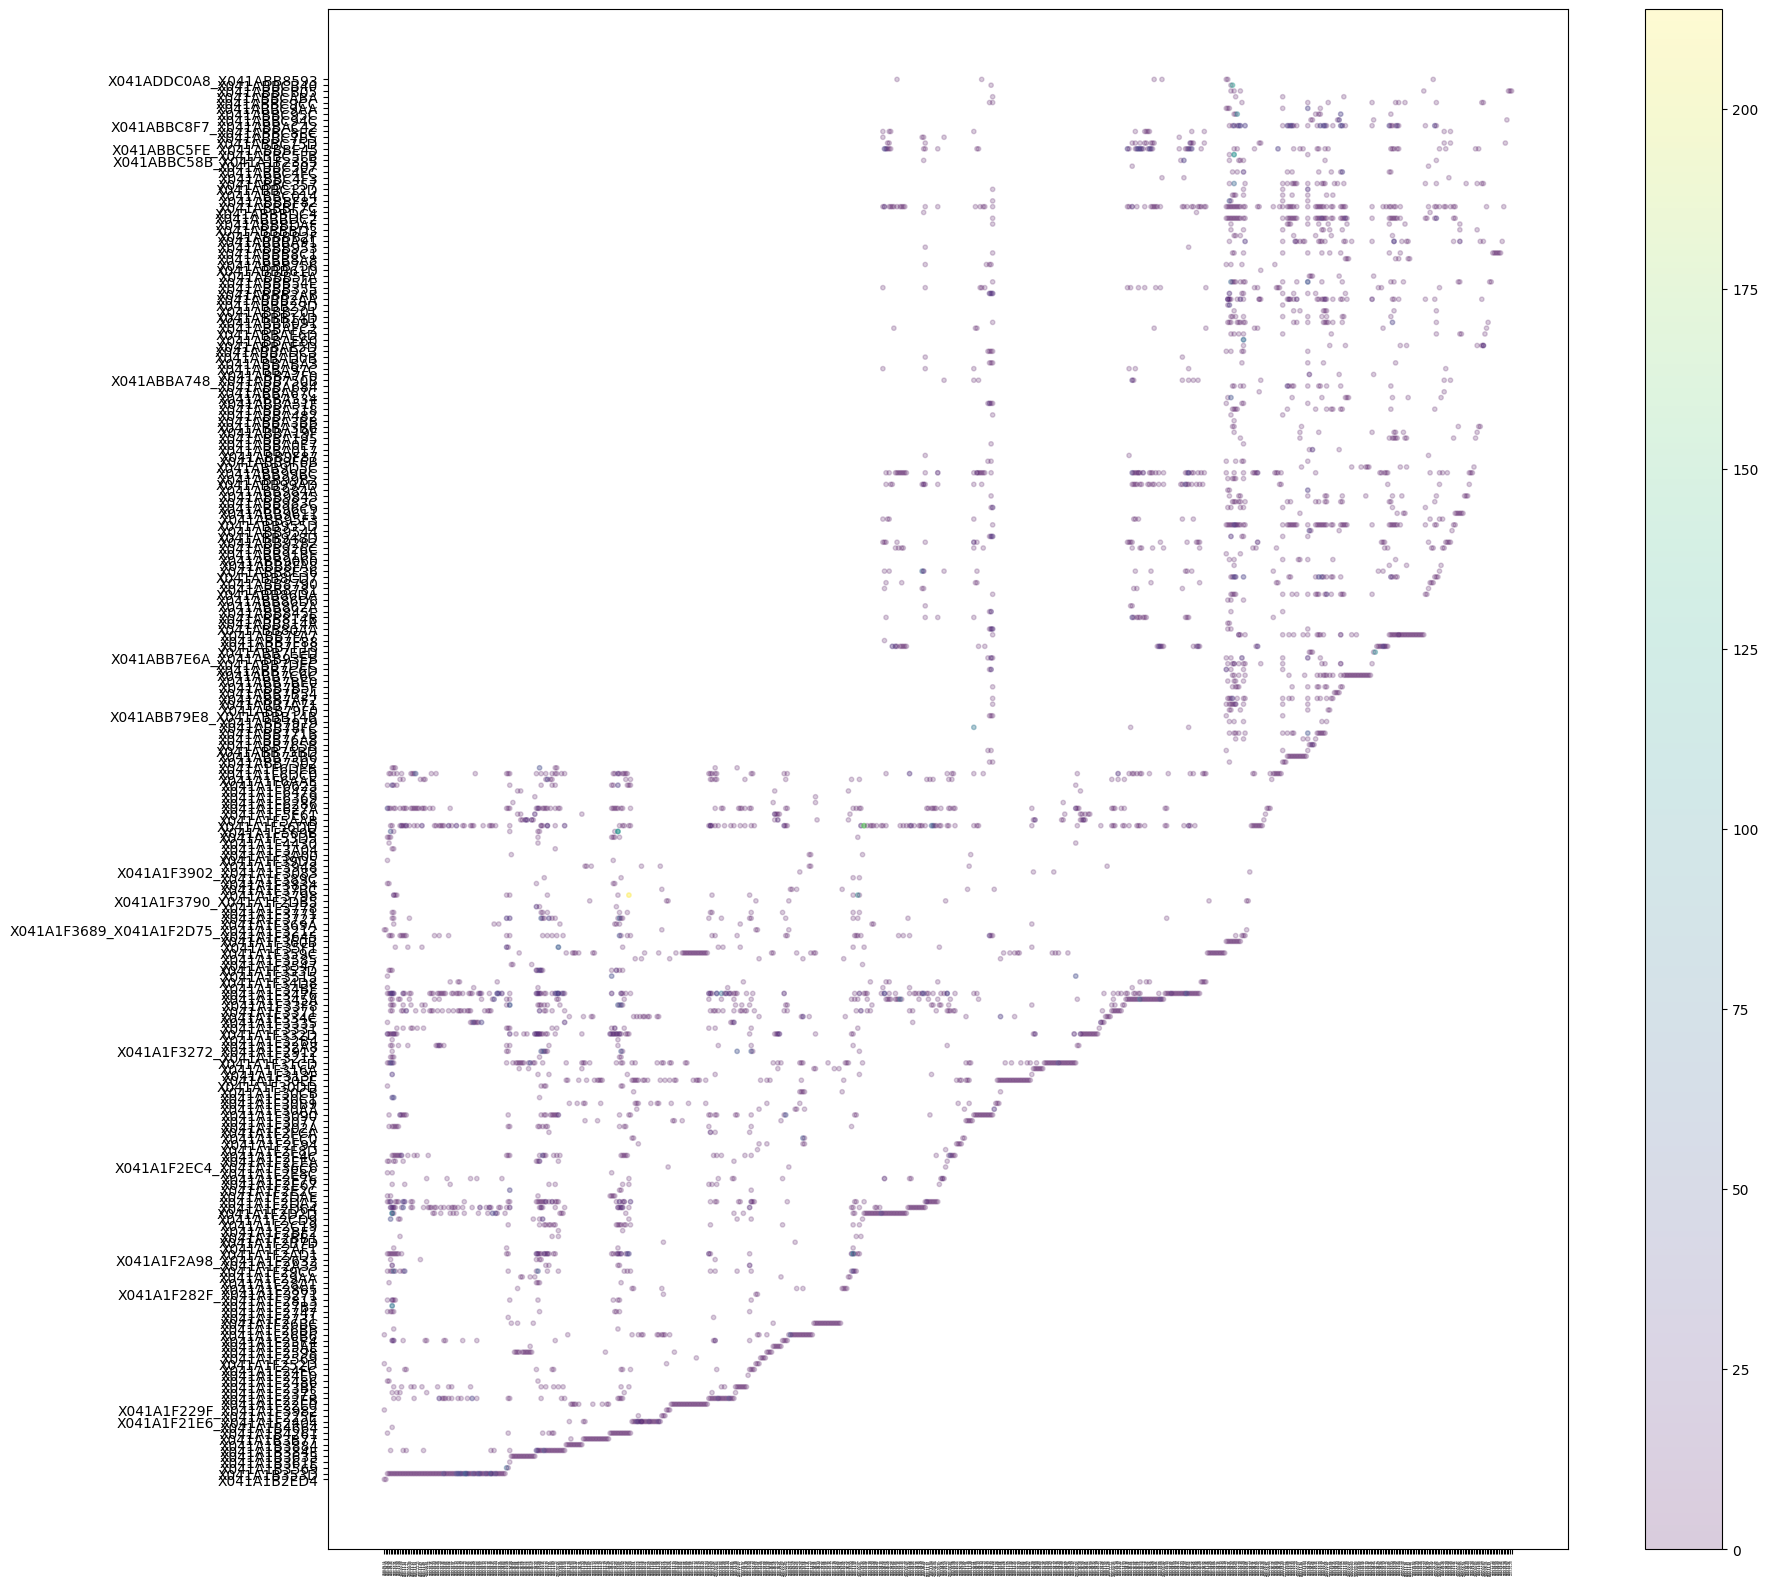

In [214]:
plt.figure(figsize=(20,20))
plt.scatter(mouse_night_df.nightstr,mouse_night_df.mouse,s=10,alpha=0.2,c=mouse_night_df.max_dists)
plt.xticks(rotation=90,fontsize=2)
plt.colorbar(
)
plt.show()

In [215]:
mouse_night_df.nightstr

0       2020-09-11
1       2020-09-16
2       2021-09-22
3       2021-09-26
4       2021-09-30
           ...    
4074    2022-07-08
4075    2022-07-09
4076    2022-07-22
4077    2022-09-19
4078    2022-09-20
Name: nightstr, Length: 4079, dtype: object

In [222]:
mouse_night_df=mouse_night_df.sort_values(by='nightstr')

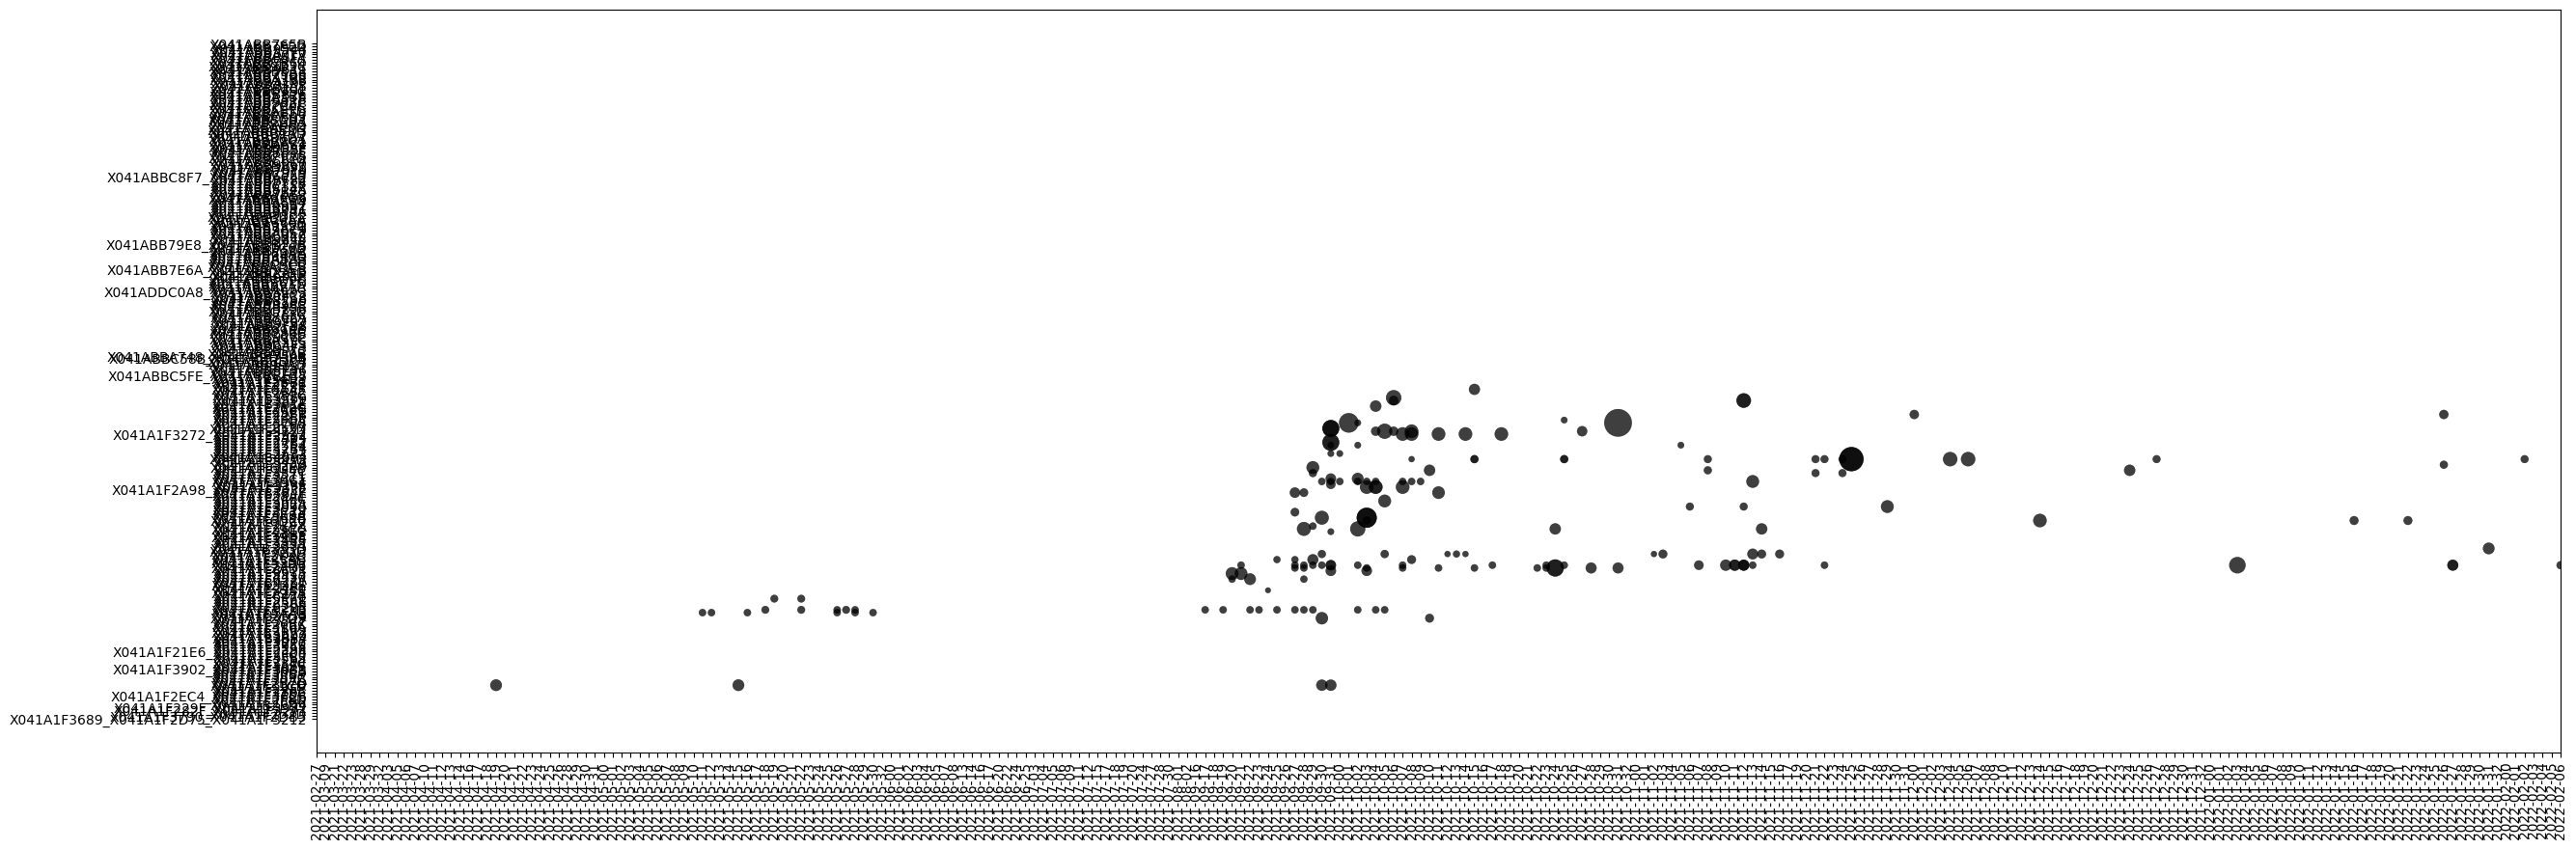

In [240]:
plt.figure(figsize=(30,10))
plt.scatter(mouse_night_df.nightstr,mouse_night_df.mouse,c='k',alpha=0.5,s=2*mouse_night_df.max_dists,linewidth=0)
plt.xticks(rotation=90,fontsize=10)
plt.xlim(150,400)
plt.show()

In [274]:
mouse_night_df

,mouse,nightstr,num_loggers,loggers,GPS_lats,GPS_longs,no_checkins,max_dists
1958,X041A1F3689_X041A1F2D75_X041A1F3212,2020-09-06,1,0843,51.699732,-5.274423,2,0.000000
2022,X041A1F3790_X041A1F2DB5,2020-09-06,1,0843,51.699732,-5.274423,1,0.000000
2023,X041A1F3790_X041A1F2DB5,2020-09-07,1,0843,51.699732,-5.274423,1,0.000000
357,X041A1F252D,2020-09-09,1,0843,51.699732,-5.274423,6,0.000000
492,X041A1F282F_X041A1F3271,2020-09-09,1,0843,51.699732,-5.274423,7,0.000000
...,...,...,...,...,...,...,...,...
4027,X041ABBC94C,2023-04-29,1,0816,51.695023,-5.287580,1,0.000000
2987,X041ABB9544,2023-04-30,1,080E,51.695251,-5.287888,27,0.000000
2705,X041ABB7EED,2023-04-31,2,080E,51.695251,-5.287888,2,98.565312
2706,X041ABB7EED,2023-04-31,2,0841,51.696126,-5.287659,1,98.565312


obs 0.0 20.60184823191932
quarry 0.0 33.09923648786416


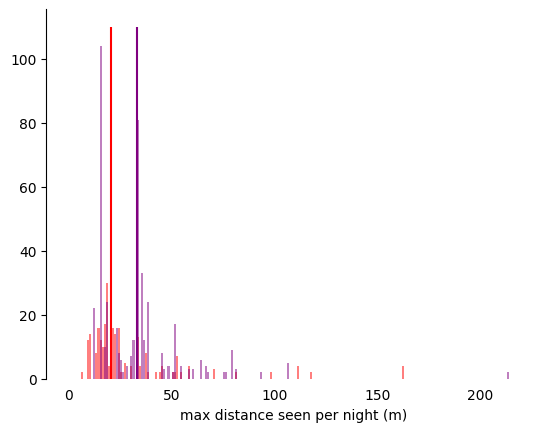

In [272]:
fig,ax = plt.subplots()
ax.vlines(20.60184823191932,ymin=0,ymax=110,color='red')
ax.vlines(33.09923648786416,ymin=0,ymax=110,color='purple')

ax.hist(mouse_night_df.max_dists[(mouse_night_df.max_dists>0) & (mouse_night_df.GPS_longs<-5.28)],bins=np.arange(0,220,1),color='red',alpha=0.5)
ax.hist(mouse_night_df.max_dists[(mouse_night_df.max_dists>0) & (mouse_night_df.GPS_longs>-5.28)],bins=np.arange(0,220,1),color='purple',alpha=0.5)
ax.spines['bottom'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.xaxis.set_ticks_position('none')
ax.set_xlabel('max distance seen per night (m)')
print('obs',np.median(mouse_night_df.max_dists[mouse_night_df.GPS_longs<-5.28]),np.median(mouse_night_df.max_dists[(mouse_night_df.max_dists>0) & (mouse_night_df.GPS_longs<-5.28)]))
print('quarry',np.median(mouse_night_df.max_dists[mouse_night_df.GPS_longs>-5.28]),np.median(mouse_night_df.max_dists[(mouse_night_df.max_dists>0) & (mouse_night_df.GPS_longs>-5.28)]))


quarry 3.9888723461971556 4.497613912696504
obs 7.283953480173573 7.71659846231944


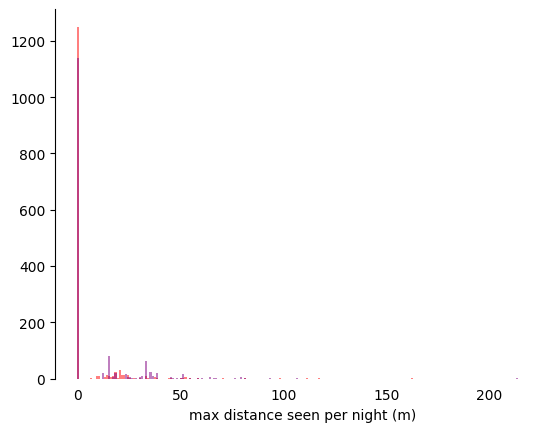

In [283]:
fig,ax = plt.subplots()
#ax.vlines(20.60184823191932,ymin=0,ymax=110,color='red')
#ax.vlines(33.09923648786416,ymin=0,ymax=110,color='purple')
x=1
ax.hist(mouse_night_df.max_dists[(mouse_night_df.no_checkins>x) & (mouse_night_df.GPS_longs<-5.28)],bins=np.arange(0,220,1),color='red',alpha=0.5)
ax.hist(mouse_night_df.max_dists[(mouse_night_df.no_checkins>x) & (mouse_night_df.GPS_longs>-5.28)],bins=np.arange(0,220,1),color='purple',alpha=0.5)
ax.spines['bottom'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.xaxis.set_ticks_position('none')
ax.set_xlabel('max distance seen per night (m)')
print('quarry',np.average(mouse_night_df.max_dists[mouse_night_df.GPS_longs<-5.28]),np.average(mouse_night_df.max_dists[(mouse_night_df.no_checkins>x) & (mouse_night_df.GPS_longs<-5.28)]))
print('obs',np.average(mouse_night_df.max_dists[mouse_night_df.GPS_longs>-5.28]),np.average(mouse_night_df.max_dists[(mouse_night_df.no_checkins>x) & (mouse_night_df.GPS_longs>-5.28)]))


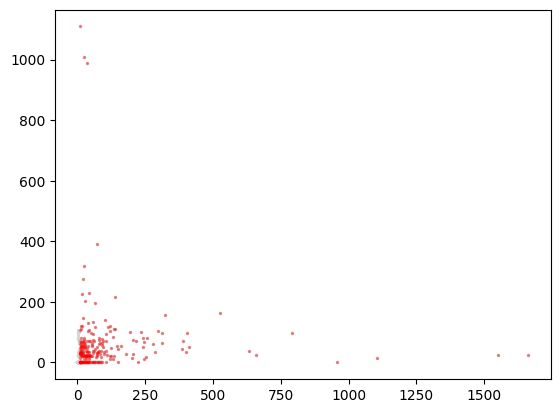

In [90]:
x=8
plt.scatter(mouse_stat_df.no_checkins,mouse_stat_df.max_dists,s=2,c='lightgray')
plt.scatter(mouse_stat_df.no_checkins[mouse_stat_df.no_checkins>x],mouse_stat_df[mouse_stat_df.no_checkins>x].max_dists,s=2,c='r',alpha=0.3)

Text(0, 0.5, 'number of check ins per mouse')

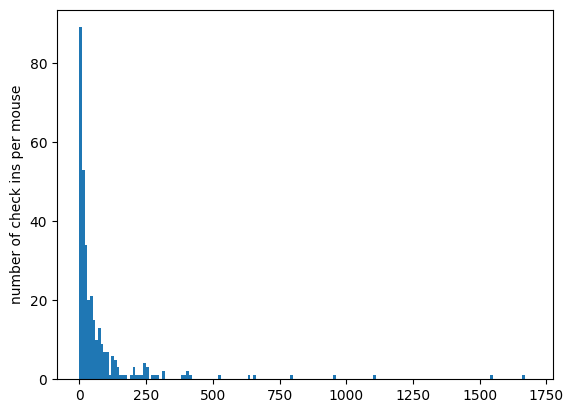

In [283]:
plt.hist(mouse_stat_df.no_checkins,bins=np.arange(0,1700,10))
plt.ylabel('number of check ins per mouse')

24.378518660571523


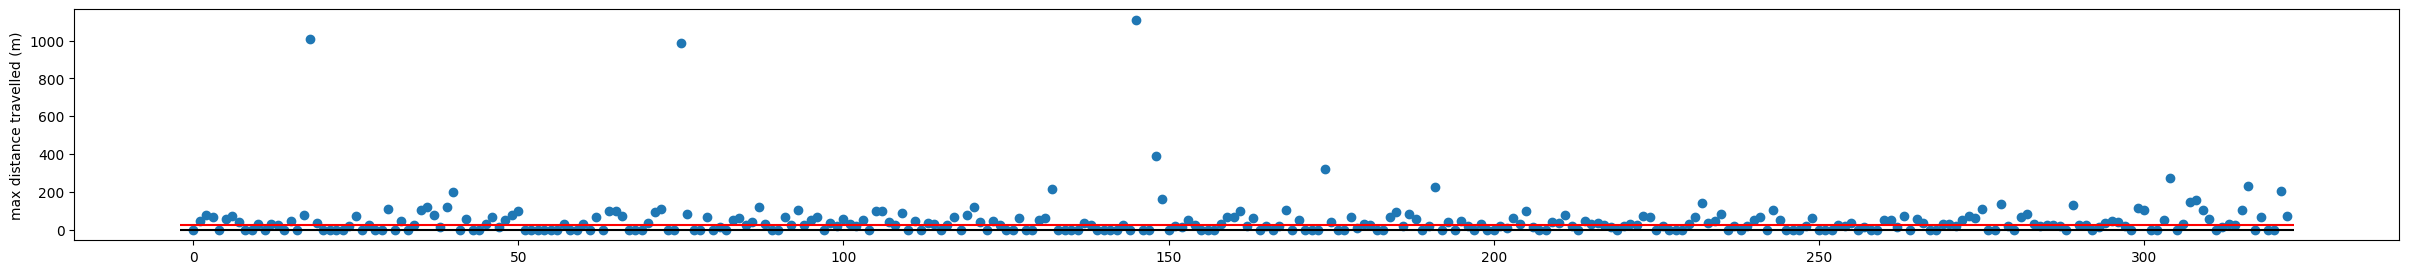

In [337]:
plt.figure(figsize=(30,3))
plt.hlines(y=0,xmin=-2,xmax=len(max_dists),color='k')
plt.hlines(y=np.median(max_dists),xmin=-2,xmax=len(max_dists),color='r')
plt.scatter(mouse_stat_df.index,mouse_stat_df.max_dists)
plt.ylabel('max distance travelled (m)')
#plt.ylim(-5,500)
#plt.yscale('log')
print(np.median(max_dists))

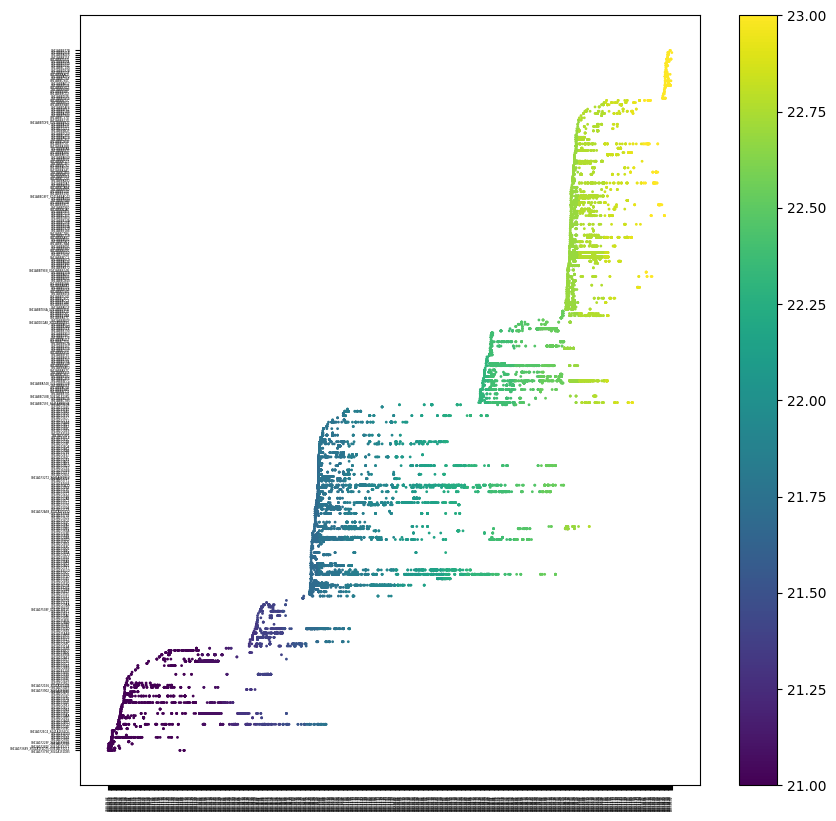

In [338]:
plt.figure(figsize=(10,10))
plt.xticks(fontsize=2)
plt.yticks(fontsize=2)
plt.tick_params('x',rotation=90)
plt.scatter(capturereads.date_actual,capturereads.mouse_ID,s=1,c=capturereads.yearmonth)
plt.clim(21,23)
plt.colorbar()

### mouse consistency
- for each mouse (y), how many times do we see them (x)

### mouse range per night, week, month
- number of readers/night 
- if 0, dist = NaN, if 1, dist = 0, if >1, calculate

### how 'sticky' are they? when do abrupt/changed movements occur if they do occur?

In [192]:
# how many mice do we see each night
capturereads.columns

Index(['Tag_IDX', 'location_found_cleaned', 'logger_id_season', 'datetime',
       'LOGGER_ID', 'WIRELESS_ID', 'motion_det', 'tempC', 'hum.', 'AMP1ADC',
       'AMP2ADC', 'batV_L', 'batV_NL', 'int.tempC', 'Tag_ID', 'Err', 'Line',
       'Pdir', 'ext.tempC', 'Comment', 'Day', 'Month', 'Yearx', 'Hours',
       'Minutes', 'Seconds', 'logger_season', 'logger_id', 'location_found',
       'trip', 'Yeary', 'Trapping_date', 'collection_date', 'Season',
       'Trapping_site', 'Trapping_point', 'Garmin_GPS', 'Garmin_ID',
       'GPS_latitude', 'GPS_longitude', 'No_trappingpoints', 'Comments',
       'Merge_GPS_coordinates_by', 'unique_flag_location', 'datetime2',
       'time_difference', 'preceding_same', 'first_value', 'winter_interval',
       'date_actual', 'date', 'mouse_ID', 'tag_id', 'dummy', 'yearmonth'],
      dtype='object')

## WORKING HERE

In [ ]:
numofreads=[]
uniquemice=[]
uniquedates = []

## goal:
#  MAKE A DATA FRAME that's 'long' such that the cols are 
# lat, long, arbit_dist, date (keep all unique dates! I think this can be done with groupby), # of mice per night
# make a plot of y = latitudes, x = date, size = # mice


''' 

for idx in capturereads.index:
    lat=capturereads.loc[idx,'GPS_latitude']
    long=capturereads.loc[idx,'GPS_longitude']
    arbit_dist.append(haversine((minlat,minlong),(lat,long)))
capturereads['arbit_dist']=arbit_dist

'''

for unique_lat in np.unique(capturereads.GPS_latitude):
    latdf = capturereads[capturereads.GPS_latitude==unique_lat].reset_index(drop=True)
    if np.unique(latdf.GPS_longitude) > 2:
        print('manually look at {}'.format(unique_lat))
    else:
        uniquedates.append(uniquedate)
        numofreads.append(len(capturereads[capturereads.date_actual==uniquedate]))
        uniquemice.append(len(np.unique(capturereads.mouse_ID[capturereads.date_actual==uniquedate])))

daily_stats = pd.DataFrame(columns=['unique_date','reads_no','mice_no','logger_no'])
daily_stats.unique_date = alldates
daily_stats.reads_no = numofreads
daily_stats.mice_no = uniquemice
daily_stats.logger_no = uniqueloggers
daily_stats[['yyyy','mm','dd']]=daily_stats.unique_date.str.split('-',expand=True)
daily_stats['yearmo']=(daily_stats.yyyy.astype(int)-2020)*12 + daily_stats.mm.astype(int)

In [341]:
alldates=[]
numofreads=[]
uniquemice=[]
uniqueloggers=[]

for uniquedate in np.unique(capturereads.date_actual):
    alldates.append(uniquedate)
    numofreads.append(len(capturereads[capturereads.date_actual==uniquedate]))
    uniquemice.append(len(np.unique(capturereads.mouse_ID[capturereads.date_actual==uniquedate])))
    uniqueloggers.append(len(np.unique(capturereads.LOGGER_ID[capturereads.date_actual==uniquedate])))

daily_stats = pd.DataFrame(columns=['unique_date','reads_no','mice_no','logger_no'])
daily_stats.unique_date = alldates
daily_stats.reads_no = numofreads
daily_stats.mice_no = uniquemice
daily_stats.logger_no = uniqueloggers
daily_stats[['yyyy','mm','dd']]=daily_stats.unique_date.str.split('-',expand=True)
daily_stats['yearmo']=(daily_stats.yyyy.astype(int)-2020)*12 + daily_stats.mm.astype(int)

In [1]:
plt.scatter(daily_stats.reads_no,daily_stats.mice_no,c='k',s=3,alpha=0.2)
plt.xlabel('reads per night')
plt.ylabel('unique mice per night')

NameError: name 'plt' is not defined

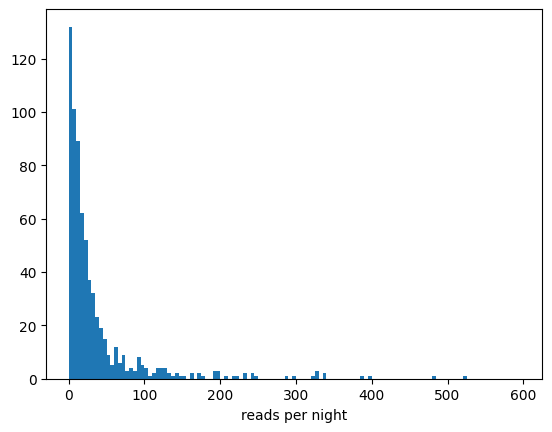

In [340]:
plt.hist(daily_stats.reads_no,bins=np.arange(0,600,5))
plt.xlabel('reads per night')
plt.show()

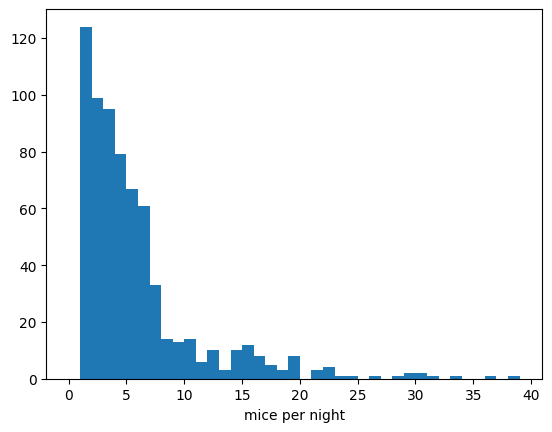

In [339]:
plt.hist(daily_stats.mice_no,bins=np.arange(0,40,1))
plt.xlabel('mice per night')
plt.show()

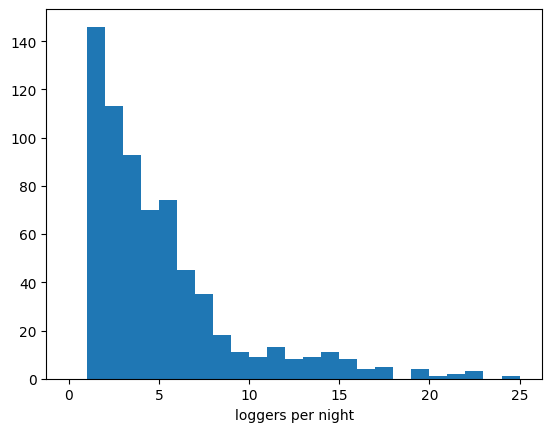

In [343]:
plt.hist(daily_stats.logger_no,bins=np.arange(0,26,1))
plt.xlabel('loggers per night')
plt.show()

In [ ]:
# for each reader location, plot mice per night max
daily_stats.mice_no

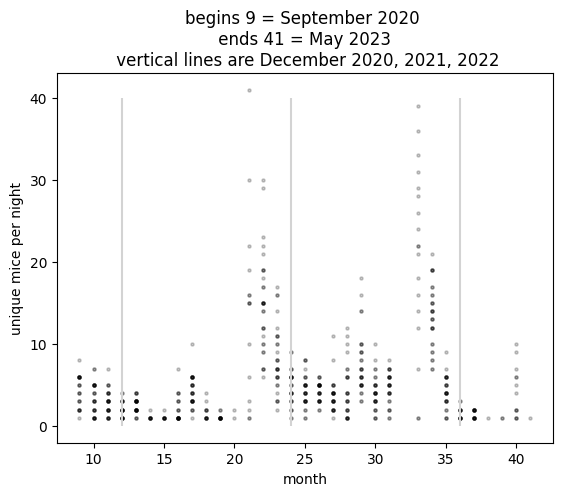

In [296]:
plt.vlines(x=12,ymin=0,ymax=40,color='lightgray')
plt.vlines(x=24,ymin=0,ymax=40,color='lightgray')
plt.vlines(x=36,ymin=0,ymax=40,color='lightgray')
plt.scatter(daily_stats.yearmo,daily_stats.mice_no,c='k',alpha=0.2,s=5)
plt.ylabel('unique mice per night')
plt.xlabel('month')
plt.title('begins 9 = September 2020 \n ends 41 = May 2023 \n vertical lines are December 2020, 2021, 2022')
plt.show()


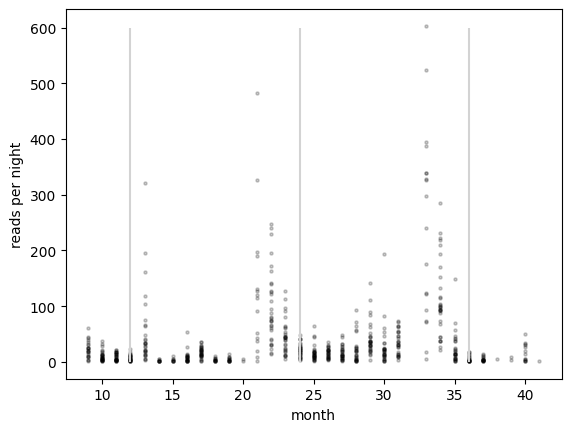

In [297]:
plt.vlines(x=12,ymin=0,ymax=600,color='lightgray')
plt.vlines(x=24,ymin=0,ymax=600,color='lightgray')
plt.vlines(x=36,ymin=0,ymax=600,color='lightgray')
plt.scatter(daily_stats.yearmo,daily_stats.reads_no,c='k',alpha=0.2,s=5)
plt.ylabel('reads per night')
plt.xlabel('month')
plt.show()

In [ ]:
# find 

0